Question 1a - Compute
output with the filter -
```
1  −1
1  −1
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Input image of 9x9 grid
input_image = np.zeros((9, 9))
# Fill in the 1s
input_image[2:7, 5] = 1
print("Input matrix: ")
print(input_image)

Input matrix: 
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [10]:
import scipy.signal as sig
# Filter
kernel = np.array([[1, -1], [1, -1]])
output = sig.convolve2d(input_image, kernel, mode='valid')
print("\nOutput for 2D convolve:")
print(output)


Output for 2D convolve:
[[ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -1.  0.  0.]
 [ 0.  0.  0.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  1. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]]


Question 1b - Design a one dimensional filter of Gaussian, first
derivative of Gaussian, and the second derivative of Gaussian
with sigma = 2.4. Plot these filters with clear annotations
along X and Y direction.

In [13]:
sigma = 2.4
# 1D filter
x = np.arange(-7, 8, 1)
gauss = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-x**2 / (2 * sigma**2))
gauss /= np.sum(gauss)  # Normalize so it doesn't change brightness

# First derivative of Gaussian (DoG)
first_derivative_gauss = -(x / (sigma**2)) * gauss

second_derivative_gauss = ((x**2 - sigma**2) / (sigma**4)) * gauss


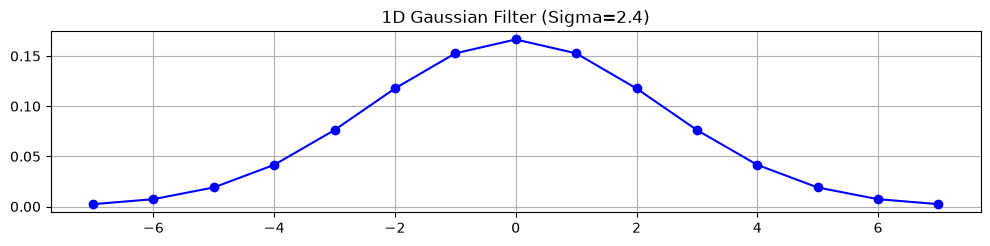

In [14]:
# Plot 1D
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(x, gauss, 'b-o')
plt.title(f'1D Gaussian Filter (Sigma={sigma})')
plt.grid(True)

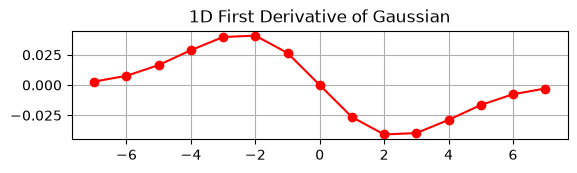

In [16]:
plt.subplot(3, 1, 2)
plt.plot(x, first_derivative_gauss, 'r-o')
plt.title('1D First Derivative of Gaussian')
plt.grid(True)


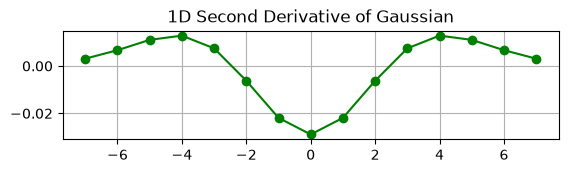

In [21]:
plt.subplot(3, 1, 3)
plt.plot(x, second_derivative_gauss, 'g-o')
plt.title('1D Second Derivative of Gaussian')
plt.grid(True)




In [35]:
# Apply the filters to the input image
from scipy.ndimage import convolve1d
# Smoothing
img_smoothed = convolve1d(input_image, gauss, axis=1)

# First Derivative (Edge detection)
img_edge_1st = convolve1d(input_image, first_derivative_gauss, axis=1)

# Second Derivative (Zero-crossing detection)
img_edge_2nd = convolve1d(input_image, second_derivative_gauss, axis=1)

Question - 4 - Using Lenna Image

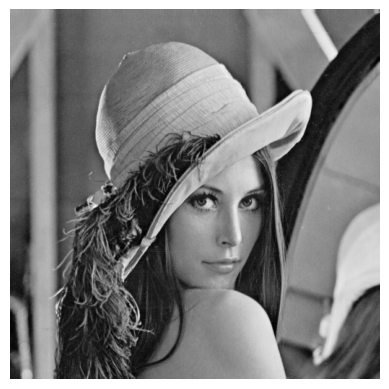

In [17]:
from PIL import Image
import numpy as np

def read_image(image_path: str, grayscale: bool = False) -> np.ndarray:
    img = Image.open(image_path)
    rgb = np.asarray(img, dtype=np.float64) / 255.0
    if grayscale:
        return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    return rgb

def display_rgb_image(rgb):
    plt.imshow(rgb, cmap='gray'); plt.axis("off"); plt.show()

img = read_image("lenna.png", grayscale=True)  # Shape: (512, 512)  
display_rgb_image(img)

4a - Implement a derivative of Gaussian, with sigma of 1, 3, and 5, and convolve with the
Lenna image. Show the derivatives in X and Y directions. Compute and show magnitude
and edge direction

In [ ]:
# 1D Gaussian Kernel
def make_gaussian(sigma, size=15):
    x = np.arange(-size // 2 + 1, size // 2 + 1)
    g = np.exp(-x**2 / (2 * sigma**2))
    g /= g.sum()  # normalize
    return g

In [56]:
# First and second derivative of Gaussian
def make_gaussian_first_derivative(sigma, size=15):
    x = np.arange(-size // 2 + 1, size // 2 + 1)
    g = np.exp(-x**2 / (2 * sigma**2))
    g /= g.sum()
    g_prime = -(x / sigma**2) * g
    return g_prime


def make_gaussian_second_derivative(sigma, size=31):
    x = np.arange(-size // 2 + 1, size // 2 + 1)
    g = np.exp(-x**2 / (2 * sigma**2))
    g /= g.sum()
    g_double_prime = ((x**2 / sigma**4) - (1 / sigma**2)) * g
    return g_double_prime

In [61]:
def dog_filter(image, sigma):
    # Compute Gx, Gy, magnitude, and direction using 1D convolutions.
    g = make_gaussian(sigma)
    g_prime = make_gaussian_first_derivative(sigma)

    # Gx: derivative along x, smoothing along y
    Gx = convolve1d(convolve1d(image, g_prime, axis=1), g, axis=0)

    # Gy: derivative along y, smoothing along x
    Gy = convolve1d(convolve1d(image, g_prime, axis=0), g, axis=1)

    magnitude = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx)  # range: -pi to pi

    return Gx, Gy, magnitude, direction

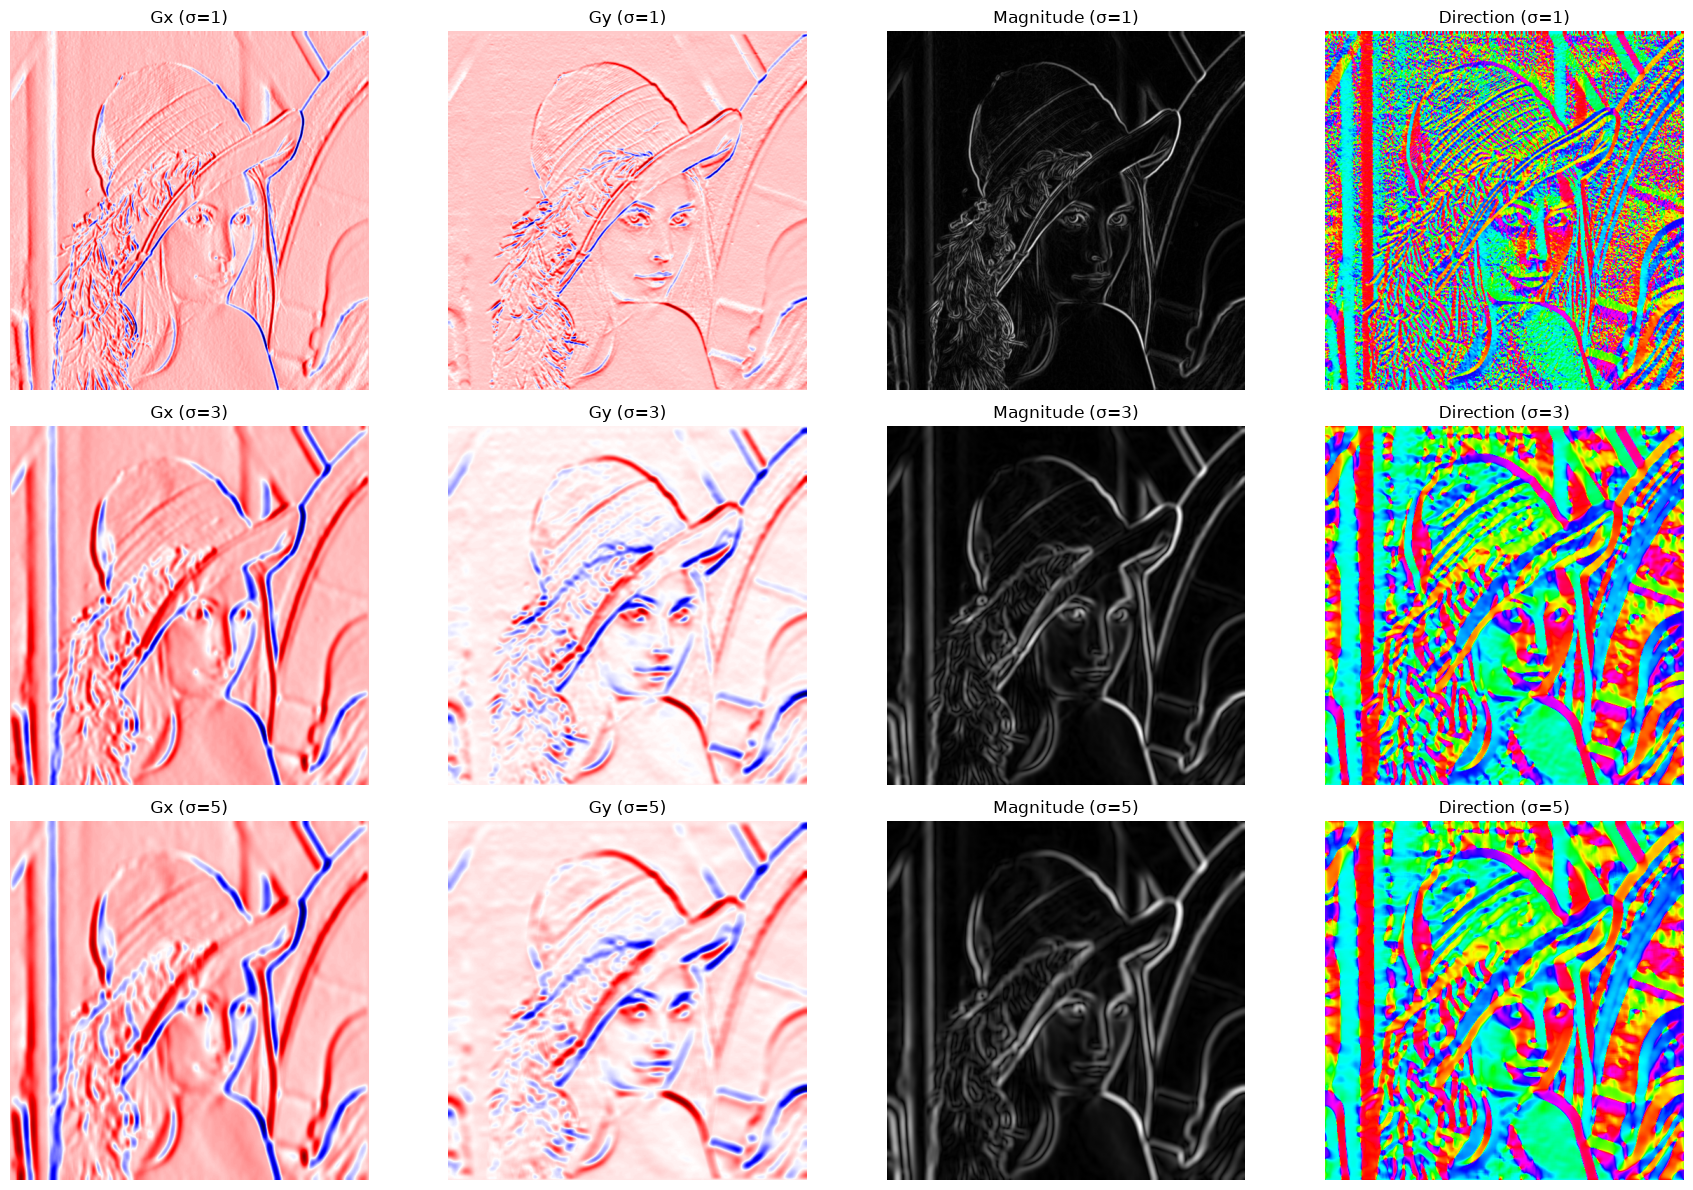

In [60]:
# Plot the results for different sigma values for the DoG filter
sigmas_dog = [1, 3, 5]
fig, axes = plt.subplots(len(sigmas_dog), 4, figsize=(18, 12))

for i, sigma in enumerate(sigmas_dog):
    Gx, Gy, mag, direction = dog_filter(img, sigma)

    axes[i, 0].imshow(Gx, cmap='seismic');  axes[i, 0].set_title(f'Gx (σ={sigma})')
    axes[i, 1].imshow(Gy, cmap='seismic');  axes[i, 1].set_title(f'Gy (σ={sigma})')
    axes[i, 2].imshow(mag, cmap='gray');    axes[i, 2].set_title(f'Magnitude (σ={sigma})')
    axes[i, 3].imshow(direction, cmap='hsv'); axes[i, 3].set_title(f'Direction (σ={sigma})')

    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Laplacian of Gaussian

def log_filter(image, sigma):
    """
    Laplacian of Gaussian via separable convolution:
        LoG = G''(x)G(y) + G(x)G''(y)
    """
    g = make_gaussian(sigma, size=31)
    g_double_prime = make_gaussian_second_derivative(sigma, size=31)

    LoG = (convolve1d(convolve1d(image, g_double_prime, axis=1), g, axis=0) +
           convolve1d(convolve1d(image, g, axis=1), g_double_prime, axis=0))
    return LoG

def zero_crossing(LoG):
    """
    Find zero-crossings: pixels whose neighbor has the opposite sign.
    Checks 4 directions: horizontal, vertical, and both diagonals.
    """
    zc = np.zeros_like(LoG, dtype=bool)
    for shift in [(0, 1), (1, 0), (1, 1), (1, -1)]:
        rolled = np.roll(np.roll(LoG, shift[0], axis=0), shift[1], axis=1)
        zc |= (LoG * rolled < 0)
    return zc


In [79]:
def draw_contours(ax, image, zero_crossings, title):
    """
    Display the original image and draw the zero-crossing
    pixels as red dots on top.
    """
    ax.imshow(image, cmap='gray')
    # Draw red dots where zero-crossings are True
    ys, xs = np.where(zero_crossings)
    ax.scatter(xs, ys, s=1, c='red', marker='.')
    ax.set_title(title)
    ax.axis('off')

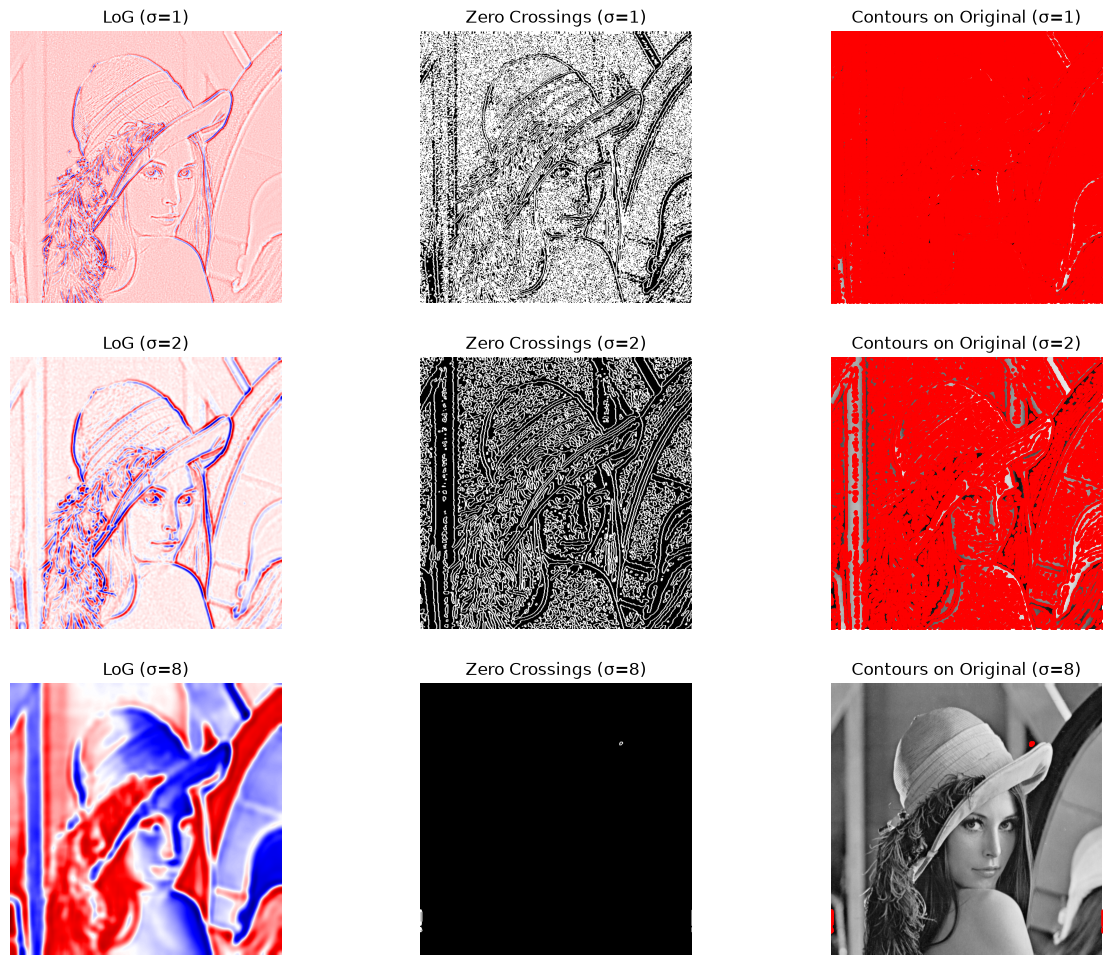

In [80]:
# Zero-Crossings at sigma = 1, 2, 8 
sigmas_log = [1, 2, 8]
fig, axes = plt.subplots(len(sigmas_log), 3, figsize=(15, 12))

for i, sigma in enumerate(sigmas_log):
    LoG = log_filter(img, sigma)
    zc = zero_crossing(LoG)

    axes[i, 0].imshow(LoG, cmap='seismic')
    axes[i, 0].set_title(f'LoG (σ={sigma})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(zc, cmap='gray')
    axes[i, 1].set_title(f'Zero Crossings (σ={sigma})')
    axes[i, 1].axis('off')

    draw_contours(axes[i, 2], img, zc, f'Contours on Original (σ={sigma})')

σ=1: The filter is narrow. It detects fine details like hair strands, feather texture, eye lashes. But it also detects noise and magnitude image looks grainy.

σ = 2 or 3: Major edges (face, hat brim) are strong. Texture is smoothed away.

σ = 5 to 8: The filter is wide. Only the coarsest structures are visible such as the outline of the shoulder, the boundary of the hat. Everything else is blurred.